# Task 3 — Variational Autoencoder

In [ ]:
!pip install -q torch torchvision matplotlib tqdm einops

In [27]:
# Imports and device
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import trange, tqdm
import json
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [28]:
# Import VAE from architecture.py
try:
    import architecture
    VAEClass = architecture.VAE
    print('Loaded VAE from architecture.py')
except Exception as e:
    print(f'Error loading architecture.py: {e}')
    print('Please ensure architecture.py is in the working directory')
    raise

Loaded VAE from architecture.py


In [29]:
# Data loaders — FashionMNIST
transform = transforms.Compose([transforms.ToTensor()])
dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
testset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
val_size = 5000
train_size = len(dataset) - val_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])
BATCH = 64
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(testset, batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
print('Dataset sizes — train, val, test:', len(train_ds), len(val_ds), len(testset))

Dataset sizes — train, val, test: 55000 5000 10000


In [ ]:
# Model, optimizer, hyperparams
latent_dim = 20 
model = VAEClass(latent_dim=latent_dim).to(device)
opt = optim.Adam(model.parameters(), lr=1e-3)
EPOCHS = 10
print('Model params:', sum(p.numel() for p in model.parameters()))
print('Latent dimension:', latent_dim)
print(f'Training for {EPOCHS} epochs')

Model params: 1691369
Latent dimension: 20
Training for 10 epochs


In [31]:
# Loss (MSE + KL)
mse = nn.MSELoss(reduction='sum')
def vae_loss(recon, x, mu, logvar, beta=1.0):
    B = x.size(0)
    recon_loss = mse(recon, x) / B
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / B
    return recon_loss + beta * kld, recon_loss, kld

In [32]:
# Training and validation loops (supporting beta annealing)
def train_epoch(model, loader, opt, beta=1.0):
    model.train()
    total_loss = total_recon = total_kld = 0.0
    for x, _ in loader:
        x = x.to(device)
        opt.zero_grad()
        recon, mu, logvar = model(x)
        loss, recon_l, kld = vae_loss(recon, x, mu, logvar, beta=beta)
        loss.backward()
        opt.step()
        total_loss += loss.item() * x.size(0)
        total_recon += recon_l.item() * x.size(0)
        total_kld += kld.item() * x.size(0)
    n = len(loader.dataset)
    return total_loss / n, total_recon / n, total_kld / n

def validate_epoch(model, loader, beta=1.0):
    model.eval()
    total_loss = total_recon = total_kld = 0.0
    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device)
            recon, mu, logvar = model(x)
            loss, recon_l, kld = vae_loss(recon, x, mu, logvar, beta=beta)
            total_loss += loss.item() * x.size(0)
            total_recon += recon_l.item() * x.size(0)
            total_kld += kld.item() * x.size(0)
    n = len(loader.dataset)
    return total_loss / n, total_recon / n, total_kld / n

In [33]:

# Trg Config
EPOCHS = 10

mse_loss = torch.nn.MSELoss(reduction="mean")

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

warmup_epochs = 10

def kl_beta(epoch):
    """Linear KL warm‑up schedule"""
    return min(1.0, epoch / warmup_epochs)


In [34]:
# Run training with linear beta anneal over anneal_epochs
history = {'train_loss':[], 'train_recon':[], 'train_kld':[], 'val_loss':[], 'val_recon':[], 'val_kld':[]}
beta_schedule = lambda ep, E: min(1.0, (ep+1)/E)
anneal_epochs = 5
for epoch in range(EPOCHS):
    beta = beta_schedule(epoch, anneal_epochs)
    tr_loss, tr_recon, tr_kld = train_epoch(model, train_loader, opt, beta=beta)
    val_loss, val_recon, val_kld = validate_epoch(model, val_loader, beta=beta)
    history['train_loss'].append(tr_loss)
    history['train_recon'].append(tr_recon)
    history['train_kld'].append(tr_kld)
    history['val_loss'].append(val_loss)
    history['val_recon'].append(val_recon)
    history['val_kld'].append(val_kld)
    print(f'Epoch {epoch+1}/{EPOCHS} beta={beta:.3f} train_loss={tr_loss:.4f} val_loss={val_loss:.4f} train_kld={tr_kld:.4f} val_kld={val_kld:.4f}')
print('Training complete!')

Epoch 1/10 beta=0.200 train_loss=27.0593 val_loss=18.7150 train_kld=15.6323 val_kld=17.3204
Epoch 2/10 beta=0.400 train_loss=20.4838 val_loss=19.7742 train_kld=13.0539 val_kld=12.4278
Epoch 3/10 beta=0.600 train_loss=21.6254 val_loss=21.4406 train_kld=11.0579 val_kld=11.6327
Epoch 4/10 beta=0.800 train_loss=23.1232 val_loss=23.2129 train_kld=9.6399 val_kld=10.4326
Epoch 5/10 beta=1.000 train_loss=24.6483 val_loss=24.6752 train_kld=8.5944 val_kld=8.4062
Epoch 6/10 beta=1.000 train_loss=24.3725 val_loss=24.6375 train_kld=8.4992 val_kld=7.9643
Epoch 7/10 beta=1.000 train_loss=24.1628 val_loss=24.5551 train_kld=8.4513 val_kld=7.7824
Epoch 8/10 beta=1.000 train_loss=24.0344 val_loss=24.2026 train_kld=8.4653 val_kld=8.6144
Epoch 9/10 beta=1.000 train_loss=23.8666 val_loss=24.0697 train_kld=8.4324 val_kld=8.3004
Epoch 10/10 beta=1.000 train_loss=23.8020 val_loss=23.9665 train_kld=8.4323 val_kld=8.7142
Training complete!


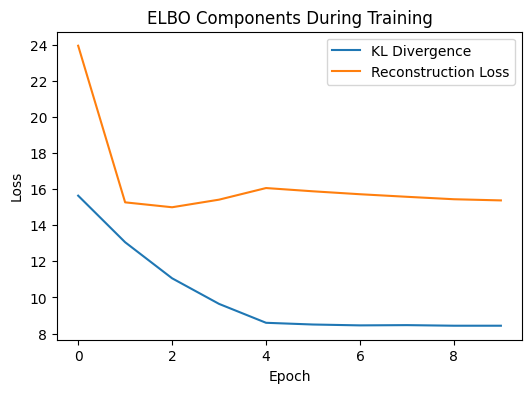

In [35]:
plt.figure(figsize=(6,4))
plt.plot(history['train_kld'], label='KL Divergence')
plt.plot(history['train_recon'], label='Reconstruction Loss')
plt.legend()
plt.title("ELBO Components During Training")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

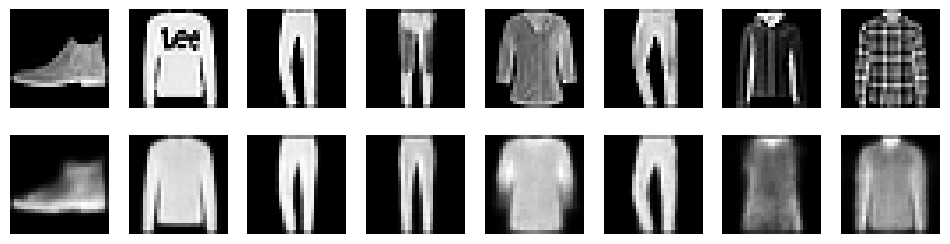

In [36]:
# Reconstructions
def show_reconstructions(model, loader, n=8):
    model.eval()
    with torch.no_grad():
        for x,_ in loader:
            x = x.to(device)
            recon, mu, logvar = model(x)
            x = x.cpu(); recon = recon.cpu()
            break
    imgs = x[:n]
    recons = recon[:n]
    fig, axs = plt.subplots(2, n, figsize=(n*1.5,3))
    for i in range(n):
        axs[0,i].imshow(imgs[i].squeeze(), cmap='gray')
        axs[0,i].axis('off')
        axs[1,i].imshow(recons[i].squeeze(), cmap='gray')
        axs[1,i].axis('off')
    plt.show()
show_reconstructions(model, test_loader, n=8)

Normal prior samples:


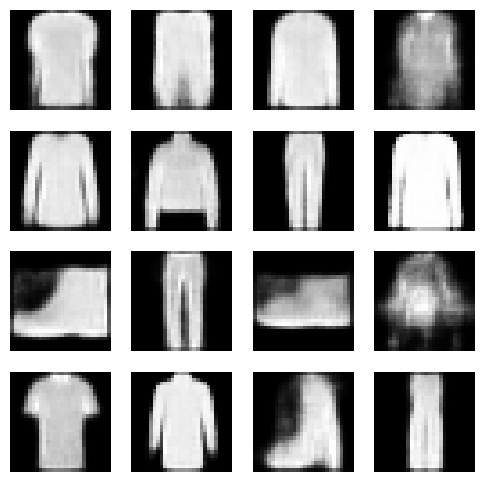

Laplace prior samples:


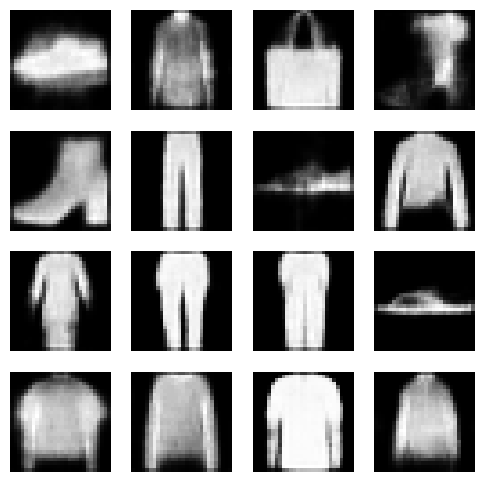

In [37]:
# Generate samples from Normal and Laplace priors
def generate_samples(model, latent_dim, prior='normal', n=16):
    model.eval()
    if prior == 'normal':
        z = torch.randn(n, latent_dim).to(device)
    elif prior == 'laplace':
        u = torch.rand(n, latent_dim).to(device) - 0.5
        z = -torch.sign(u) * torch.log1p(-2*torch.abs(u))
    else:
        raise ValueError('unknown prior')
    with torch.no_grad():
        imgs = model.decode(z).cpu()
    k = int(np.sqrt(n))
    fig, axs = plt.subplots(k, k, figsize=(k*1.5,k*1.5))
    idx = 0
    for i in range(k):
        for j in range(k):
            axs[i,j].imshow(imgs[idx].squeeze(), cmap='gray')
            axs[i,j].axis('off')
            idx += 1
    plt.show()
print('Normal prior samples:')
generate_samples(model, latent_dim, prior='normal', n=16)
print('Laplace prior samples:')
generate_samples(model, latent_dim, prior='laplace', n=16)

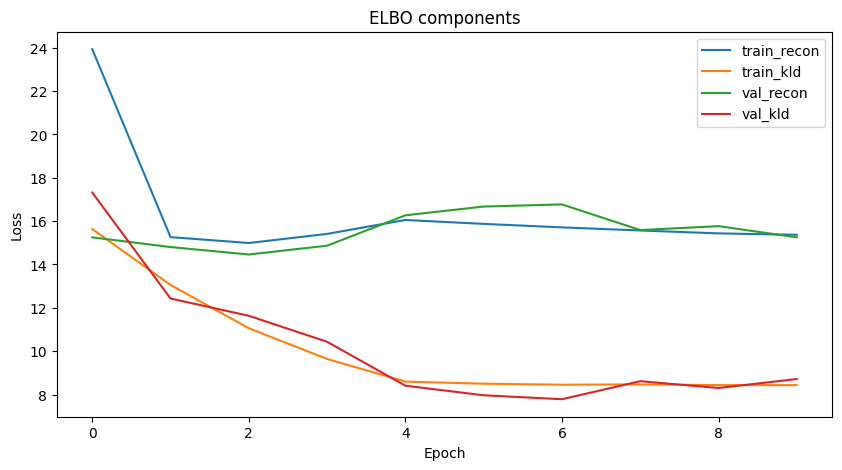

Posterior statistics:
  mu mean: 0.0059
  mu std: 0.5653
  mu shape: (64, 20)


In [38]:
# Analyze history and posterior statistics
h = history
plt.figure(figsize=(10, 5))
plt.plot(h['train_recon'], label='train_recon')
plt.plot(h['train_kld'], label='train_kld')
plt.plot(h['val_recon'], label='val_recon')
plt.plot(h['val_kld'], label='val_kld')
plt.legend()
plt.title('ELBO components')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

with torch.no_grad():
    for x,_ in test_loader:
        x = x.to(device)
        _, mu, logvar = model(x)
        break
mu = mu.cpu().numpy()
print('Posterior statistics:')
print(f'  mu mean: {mu.mean():.4f}')
print(f'  mu std: {mu.std():.4f}')
print(f'  mu shape: {mu.shape}')

In [39]:

# Handlign Posterior Collapse with KL Annealing

train_losses, val_losses = [], []
recon_losses, kl_losses = [], []

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss, train_recon, train_kl = 0.0, 0.0, 0.0

    beta = kl_beta(epoch)

    for x, _ in train_loader:
        x = x.to(device)

        optimizer.zero_grad()
        x_hat, mu, logvar = model(x)

        recon = mse_loss(x_hat, x)
        kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

        loss = recon + beta * kl
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_recon += recon.item()
        train_kl += kl.item()

    train_losses.append(train_loss / len(train_loader))
    recon_losses.append(train_recon / len(train_loader))
    kl_losses.append(train_kl / len(train_loader))

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x, _ in val_loader:
            x = x.to(device)
            x_hat, mu, logvar = model(x)
            recon = mse_loss(x_hat, x)
            kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
            val_loss += (recon + kl).item()

    val_losses.append(val_loss / len(val_loader))

    print(f"Epoch {epoch:02d} | beta={beta:.2f} | Train {train_losses[-1]:.4f} | Val {val_losses[-1]:.4f}")


Epoch 01 | beta=0.10 | Train 0.0509 | Val 0.2211
Epoch 02 | beta=0.20 | Train 0.0641 | Val 0.1552
Epoch 03 | beta=0.30 | Train 0.0724 | Val 0.1206
Epoch 04 | beta=0.40 | Train 0.0783 | Val 0.1052
Epoch 05 | beta=0.50 | Train 0.0820 | Val 0.0964
Epoch 06 | beta=0.60 | Train 0.0845 | Val 0.0930
Epoch 07 | beta=0.70 | Train 0.0857 | Val 0.0898
Epoch 08 | beta=0.80 | Train 0.0867 | Val 0.0888
Epoch 09 | beta=0.90 | Train 0.0868 | Val 0.0877
Epoch 10 | beta=1.00 | Train 0.0871 | Val 0.0878


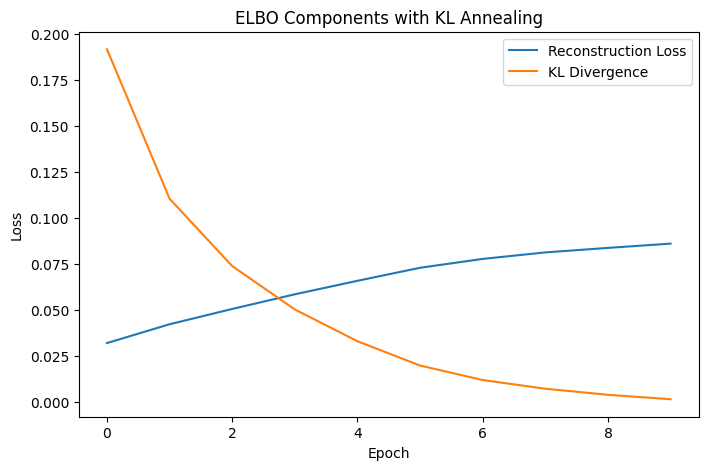

In [40]:

# Plot Reconstruction and KL losses to analyze posterior collapse
plt.figure(figsize=(8,5))
plt.plot(recon_losses, label="Reconstruction Loss")
plt.plot(kl_losses, label="KL Divergence")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("ELBO Components with KL Annealing")
plt.show()
